<a href="https://colab.research.google.com/github/janna55/SpecialistPython1/blob/main/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Тестовая работа. Исследование компаний на предмет аномалий.**


# Импорт данных

In [74]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.lines import Line2D

In [1]:
from google.colab import files
uploaded = files.upload()

Saving test_dataset.csv to test_dataset.csv


In [9]:
# Сразу определяем текстовые колонки, иначе можно потерять данные вроде первых нулей в ИНН
TEXT_COLS = ['company_id', 'company_name', 'inn', 'region', 'okved_code',
             'okved_section', 'founder_id', 'address_hash']
NUM_COLS = ['revenue', 'cost_of_goods', 'gross_profit', 'opex', 'operating_profit',
            'net_profit', 'taxes_paid', 'headcount', 'payroll_fund', 'dividends_paid']

df = pd.read_csv(
    'test_dataset.csv',
    dtype={c: 'string' for c in TEXT_COLS},
    encoding='utf-8-sig',
    keep_default_na=False,
    na_values=[''],
)

In [7]:
df.head()

,company_id,company_name,inn,ogrn_year,region,okved_code,okved_section,founder_id,address_hash,year,revenue,cost_of_goods,gross_profit,opex,operating_profit,net_profit,taxes_paid,headcount,payroll_fund,dividends_paid
0,C0001,ООО «Строй-Плюс-001»,7680402501,2019,Ненецкий АО,25.11,Производство металлоконструкций,FND-81426,5d50d22735a7,2023,28104024,18938407,9165617,4878720,4286897,3497693,4183165,21,23828697,0
1,C0001,ООО «Строй-Плюс-001»,7680402501,2019,Ненецкий АО,25.11,Производство металлоконструкций,FND-81426,5d50d22735a7,2024,28898327,16964058,11934269,2930965,9003304,6567245,4119741,20,19389865,2104070
2,C0001,ООО «Строй-Плюс-001»,7680402501,2019,Ненецкий АО,25.11,Производство металлоконструкций,FND-81426,5d50d22735a7,2025,39895305,25433458,14461847,4106215,10355632,8260411,2362873,21,13079859,3779573
3,C0002,ООО «Союз-Инвест-002»,3193008687,2008,Курганская обл.,62.01,Разработка ПО,FND-26361,38ccdf8d538d,2023,109139991,28565829,80574162,19018036,61556126,52114070,11877274,64,35427791,0
4,C0002,ООО «Союз-Инвест-002»,3193008687,2008,Курганская обл.,62.01,Разработка ПО,FND-26361,38ccdf8d538d,2024,151519856,37026148,114493708,19751888,94741820,83755447,18752342,66,84560060,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   company_id        1500 non-null   string
 1   company_name      1500 non-null   string
 2   inn               1500 non-null   string
 3   ogrn_year         1500 non-null   int64 
 4   region            1500 non-null   string
 5   okved_code        1500 non-null   string
 6   okved_section     1500 non-null   string
 7   founder_id        1500 non-null   string
 8   address_hash      1500 non-null   string
 9   year              1500 non-null   int64 
 10  revenue           1500 non-null   int64 
 11  cost_of_goods     1500 non-null   int64 
 12  gross_profit      1500 non-null   int64 
 13  opex              1500 non-null   int64 
 14  operating_profit  1500 non-null   int64 
 15  net_profit        1500 non-null   int64 
 16  taxes_paid        1500 non-null   int64 
 17  headcount     

In [ ]:
# Год можно перевести из int64 в формат int16 для скорости
df['year'] = df['year'].astype('int16')
df['ogrn_year'] = pd.to_numeric(df['ogrn_year'], errors='coerce').astype('Int16')

В датафрейме 1500 строк и 19 столбцов. Пропусков нет. Форматы импортировались правильно. Можно приступать к анализу качества данных.

# Ислледование качества данных

In [18]:
print(f'{df['company_id'].nunique()} компаний, период - {df['year'].nunique()} года, годы {df['year'].min()}–{df['year'].max()}')

500 компаний, период - 3 года, годы 2023–2025


In [52]:
# У нас 500 компаний с периодом отчетности 3 года. Далее проверим данные на ошибки выгрузки: дубли, отсутствие дат,
# отрицательная выручка или отсутствие персонала
checks = {

    'Полные дубликаты строк':        int(df.duplicated().sum()),
    'Дубли company_id + year':       int(df.duplicated(['company_id', 'year']).sum()),
    'Компаний c неполным периодом дат':        int((df.groupby('company_id')['year'].nunique() != 3).sum()),
    'Отрицательная выручка':         int((df['revenue'] < 0).sum()),
    'Нулевая численность персонала': int((df['headcount'] <= 0).sum()),
    'Дата ОГРН не ранее мин отч даты': int((df['ogrn_year'] > df['year'].min()).sum())
}
quality = pd.Series(checks, name='значение').astype(int).to_frame()
quality['статус'] = np.where(quality['значение'] == 0, 'OK', '⚠')
quality

,значение,статус
Полные дубликаты строк,0,OK
Дубли company_id + year,0,OK
Компаний c неполным периодом дат,0,OK
Отрицательная выручка,0,OK
Нулевая численность персонала,0,OK
Дата ОГРН не ранее мин отч даты,0,OK


In [31]:
# Контроль баланса
check_sum = pd.DataFrame({
    'Валовая прибыль':  (df["revenue"] - df["cost_of_goods"] - df["gross_profit"]).abs(),
    'Операционная прибыль':  (df["gross_profit"] - df["opex"] - df["operating_profit"]).abs(),
})
check_result =check_sum.sum().to_frame('Проверочное значение')
check_result['статус'] = np.where(check_result['Проверочное значение'] <= 0.01, 'OK', '⚠')
check_result


,Проверочное значение,статус
Валовая прибыль,0,OK
Операционная прибыль,0,OK


In [45]:
# Проверим длину ИНН, ничего ли не потеряли при импорте?
inn = df['inn'].str.strip()
bad = ~inn.str.len().isin([10, 12])

print(f"Некорректная длина ИНН: {bad.sum()} из {len(df)}")
df.loc[bad, ['company_id', 'inn']].head(10)

Некорректная длина ИНН: 0 из 1500


,company_id,inn


**Ошибок загрузки не обнаружено**

# Анализ аномалий

### Анализ персонала и заработных плат

#### Проверка- насколько уроень ЗП соответствует МРОТ. **Итог: соответствует**


Загрузим справочник по регионам чтобы устранить межрегиональный дисбаланс

In [88]:
FED_MROT = 27093         # федеральный МРОТ

# Региональный МРОТ.

MROT_BY_REGION = {
    'Москва': 39730,
    'Санкт-Петербург': 31250,
    'Московская обл.': 27800,
    'Ленинградская обл.': 27440,
    'Тульская обл.': 30095,
    'Калининградская обл.': 28000,
    'Республика Башкортостан': 32932,
    'Чукотский АО': int(FED_MROT * 2.0),
    'Магаданская обл.': int(FED_MROT * 1.7),
    'Республика Саха (Якутия)': int(FED_MROT * 1.7),
    'Камчатский край': int(FED_MROT * 1.6),
    'Сахалинская обл.': int(FED_MROT * 1.6),
    'Ненецкий АО': int(FED_MROT * 1.5),
    'Ямало-Ненецкий АО': int(FED_MROT * 1.5),
    'Ханты-Мансийский АО': int(FED_MROT * 1.5),
    'Мурманская обл.': int(FED_MROT * 1.4),
    'Республика Тыва': int(FED_MROT * 1.4),
    'Республика Алтай': int(FED_MROT * 1.4),
    'Республика Коми': int(FED_MROT * 1.3),
    'Красноярский край': int(FED_MROT * 1.3),
    'Иркутская обл.': int(FED_MROT * 1.3),
    'Хабаровский край': int(FED_MROT * 1.3),
    'Приморский край': int(FED_MROT * 1.3),
    'Амурская обл.': int(FED_MROT * 1.3),
    'Республика Хакасия': int(FED_MROT * 1.3),
    'Кемеровская обл.': int(FED_MROT * 1.3),
    'Томская обл.': int(FED_MROT * 1.3),
    'Архангельская обл.': int(FED_MROT * 1.2),
    'Забайкальский край': int(FED_MROT * 1.2),
    'Республика Бурятия': int(FED_MROT * 1.2),
    'Еврейская АО': int(FED_MROT * 1.2),
    'Республика Карелия': int(FED_MROT * 1.15),
    'Тюменская обл.': int(FED_MROT * 1.15),
    'Волгоградская обл.': int(FED_MROT * 1.1),
    'Краснодарский край': int(FED_MROT * 1.05),
}

In [89]:
df_upd = df.copy()
# региональный минимум; если региона нет в справочнике - берем федеральный
df_upd ['mrot'] = df_upd ['region'].map(MROT_BY_REGION).fillna(FED_MROT)

# среднемесячная зарплата на одного работника
df_upd ['avg_salary'] = df_upd ['payroll_fund'] / df_upd ['headcount'] / 12
df_upd ['salary_to_mrot'] = df_upd ['avg_salary'] / df_upd ['mrot']

Всего по одной компании за один год зп ниже МРОТ на 5%. Можно игнрировать

In [90]:
df_upd[df_upd['salary_to_mrot']<1]

,company_id,company_name,inn,ogrn_year,region,okved_code,okved_section,founder_id,address_hash,year,...,opex,operating_profit,net_profit,taxes_paid,headcount,payroll_fund,dividends_paid,mrot,avg_salary,salary_to_mrot
139,C0047,ПАО «Вектор-Групп-047»,4936688833,2021,Сахалинская обл.,47.11,Розничная торговля,FND-80912,30bb3825e8f6,2024,...,72649661,112211403,80789425,71340966,55,27158315,0,43348.0,41148.962121,0.94927


#### Численность персонала. **Итог: 13 компаний со слишком малочисленным персоналом**

In [91]:
# Посчитаем производительность труда и доля ФОТ в выручке
df_upd['rev_per_head'] = df_upd['revenue'] / df_upd['headcount']
df_upd['payroll_share'] = df_upd['payroll_fund'] / df_upd['revenue']

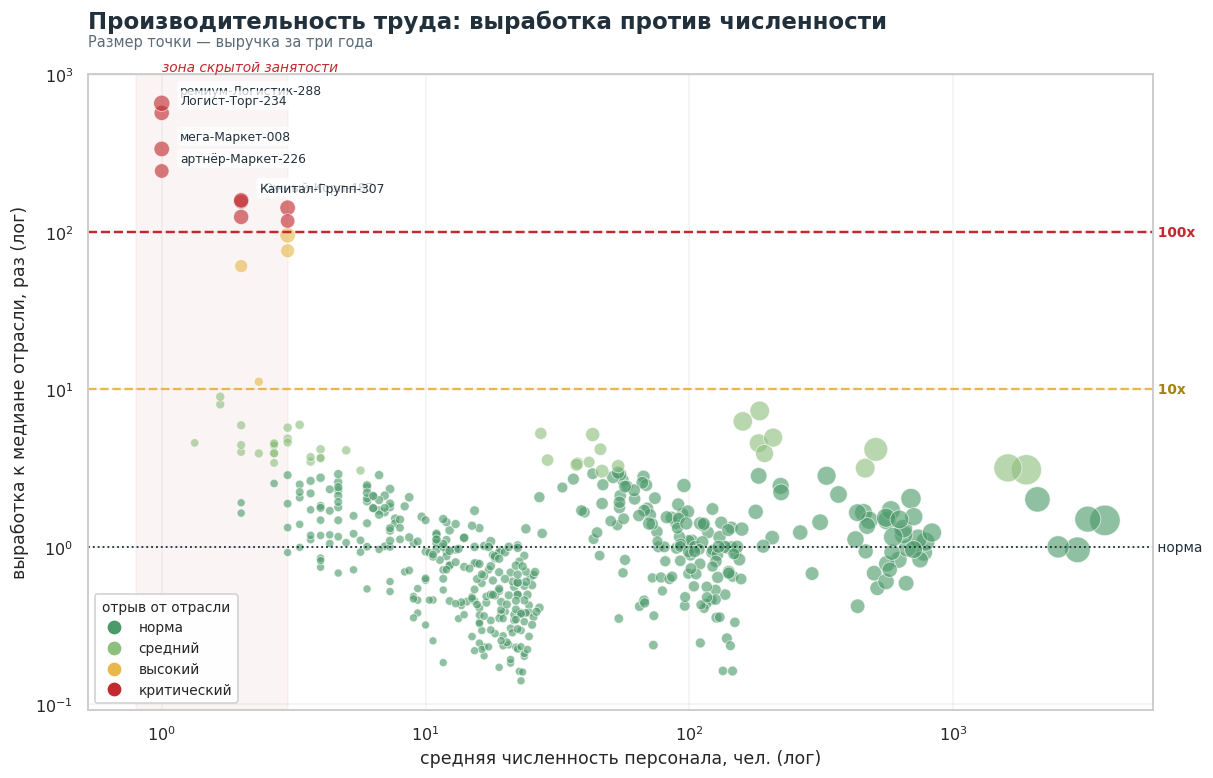

                  Компания                                  Отрасль  Кол-во сотрудников  Выработка к медиане в отрасли, превышение, раз     Уровень
ООО «Премиум-Логистик-288»                   Производство пластмасс                   1                                             658 критический
     ООО «Логист-Торг-234»                            Лесозаготовка                   1                                             572 критический
    ООО «Омега-Маркет-008»                      Аудит и бухгалтерия                   1                                             338 критический
  ООО «Партнёр-Маркет-226» Грузоперевозки автомобильным транспортом                   1                                             245 критический
       АО «Южный-Корп-487»                      Аудит и бухгалтерия                   2                                             159 критический
   ООО «Капитал-Групп-307»                                Гостиницы                   2                         

In [92]:



plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', font='DejaVu Sans', font_scale=0.95)

INK, RED, AMBER, GREEN, LIME = '#22303C', '#C1292E', '#E8B84B', '#4C9A6A', '#8FBF7F'
X3, X10, X100 = 3, 10, 100

# Сравнение с медианой отрасли
df_upd['ind_rph'] = df_upd.groupby(['okved_section', 'year'])['rev_per_head'].transform('median') # медиана выработки в своей отрасли за тот же год
df_upd['rph_ratio'] = df_upd['rev_per_head'] / df_upd['ind_rph'] # отношение к медиане

# Группируем по компаниям
comp = df_upd.groupby('company_id').agg(
    name=('company_name', 'first'),
    okved=('okved_section', 'first'),
    headcount=('headcount', 'mean'),
    revenue=('revenue', 'sum'),
    rph_ratio=('rph_ratio', 'median'),
)

# уровень по отрыву выработки от отрасли
comp['level'] = np.select(
    [comp['rph_ratio'] > X100, comp['rph_ratio'] > X10, comp['rph_ratio'] > X3],
    ['критический', 'высокий', 'средний'], default='норма')

# ---------------------------------------------------------------- график
palette = {'норма': GREEN, 'средний': LIME, 'высокий': AMBER, 'критический': RED}
order = ['норма', 'средний', 'высокий', 'критический']

fig, ax = plt.subplots(figsize=(12.5, 7.5))

# корень чтобы гиганты по выручке не заслоняли остальных
size = 20 + 380 * np.sqrt(comp['revenue'] / comp['revenue'].max())

for lvl in order:
    m = comp['level'] == lvl
    ax.scatter(comp.loc[m, 'headcount'], comp.loc[m, 'rph_ratio'], s=size[m],
               color=palette[lvl], alpha=0.62, edgecolor='white', linewidth=0.6,
               zorder=3 if lvl == 'критический' else 2)

ax.set_xscale('log')
ax.set_yscale('log')

ax.axvspan(0.8, 3, color=RED, alpha=0.05, zorder=0)
ax.axhline(1, color=INK, ls=':', lw=1.2)
ax.axhline(X10, color=AMBER, ls='--', lw=1.5)
ax.axhline(X100, color=RED, ls='--', lw=1.6)

xr = ax.get_xlim()[1]
ax.text(xr, 1, ' норма', color=INK, fontsize=9, va='center')
ax.text(xr, X10, ' 10x', color='#A5820F', fontsize=9, fontweight='bold', va='center')
ax.text(xr, X100, ' 100x', color=RED, fontsize=9, fontweight='bold', va='center')
ax.text(1.0, comp['rph_ratio'].max() * 1.6, 'зона скрытой занятости',
        fontsize=9, color=RED, style='italic')

# подписываем только шесть самых ярких выбросов
for _, r in comp.nlargest(6, 'rph_ratio').iterrows():
    ax.annotate(r['name'].strip('ОАП «»').replace('О ', '').strip(),
                xy=(r['headcount'], r['rph_ratio']), xytext=(12, 6),
                textcoords='offset points', fontsize=8, color=INK,
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.75))

ax.set_xlabel('средняя численность персонала, чел. (лог)')
ax.set_ylabel('выработка к медиане отрасли, раз (лог)')
ax.set_title('Производительность труда: выработка против численности',
             fontsize=15, fontweight='bold', color=INK, loc='left', pad=30)
ax.text(0, 1.045, 'Размер точки — выручка за три года',
        transform=ax.transAxes, fontsize=9.5, color='#5A6B78')

ax.legend(handles=[Line2D([], [], marker='o', ls='', ms=8, color=palette[l], label=l)
                   for l in order],
          title='отрыв от отрасли', fontsize=9, title_fontsize=9,
          loc='lower left', framealpha=0.95)
ax.grid(alpha=0.25)

plt.show()

# ---------------------------------------------------------------- список
flagged = (comp[comp['rph_ratio'] > X10]
           .sort_values('rph_ratio', ascending=False)
           .loc[:, ['name', 'okved', 'headcount', 'rph_ratio', 'level']]
           .rename(columns={
               'name': 'Компания',
               'okved': 'Отрасль',
               'headcount': 'Кол-во сотрудников',
               'rph_ratio': 'Выработка к медиане в отрасли, превышение, раз',
               'level': 'Уровень',
           }))

flagged['Кол-во сотрудников'] = flagged['Кол-во сотрудников'].round().astype(int)
flagged['Выработка к медиане в отрасли, превышение, раз'] = \
    flagged['Выработка к медиане в отрасли, превышение, раз'].round().astype(int)

print(flagged.to_string(index=False))


### Новый раздел

In [ ]:
  # размер группы: сколько компаний завязано на учредителя и на адрес
    a['founder_cnt'] = a['founder'].map(df.groupby('founder_id')['company_id'].nunique())
    a['address_cnt'] = a['address'].map(df.groupby('address_hash')['company_id'].nunique())

In [87]:
df_upd.columns

Index(['company_id', 'company_name', 'inn', 'ogrn_year', 'region',
       'okved_code', 'okved_section', 'founder_id', 'address_hash', 'year',
       'revenue', 'cost_of_goods', 'gross_profit', 'opex', 'operating_profit',
       'net_profit', 'taxes_paid', 'headcount', 'payroll_fund',
       'dividends_paid', 'rev_per_head', 'payroll_share', 'ind_rph',
       'rph_ratio'],
      dtype='object')

In [ ]:



PROFIT_RATE = 0.25       # ставка налога на прибыль с 2025 года


# Отрасли, где один-два человека физически не могут обеспечить оборот.
LABOR_INTENSIVE = [
    'Производство пластмасс', 'Производство металлоконструкций',
    'Производство хлебобулочных изделий', 'Производство алкогольных напитков',
    'Гостиницы', 'Рестораны и кафе', 'Частная медицина',
    'Строительство зданий', 'Электромонтажные работы', 'Лесозаготовка',
    'Розничная торговля', 'Грузоперевозки автомобильным транспортом',
]


# ------------------------------------------------------------ шаг 1: чтение

    # налоговая нагрузка по методике ФНС: уплачено / выручка
    df['burden'] = df['taxes_paid'] / df['revenue']

    # эффективная ставка; при убытке не считаем - показатель теряет смысл
    df['etr'] = np.where(df['operating_profit'] > 0,
                         df['taxes_paid'] / df['operating_profit'], np.nan)






# -------------------------------------------------- шаг 2: отраслевые нормы

def add_industry_benchmarks(df):
    """Сравниваем каждую компанию с медианой своей отрасли за тот же год.
    Медиана устойчива к выбросам, а выбросы - это как раз то, что мы ищем."""
    for col in ['burden', 'rev_per_head', 'payroll_share', 'etr']:
        df['ind_' + col] = df.groupby(['okved_section', 'year'])[col].transform('median')

    df['burden_gap'] = df['burden'] / df['ind_burden'] - 1

    df['payroll_gap'] = df['payroll_share'] / df['ind_payroll_share'] - 1
    return df


# ------------------------------------------------- шаг 3: свод по компаниям

def aggregate_companies(df):
    """Сворачиваем три года в одну строку на компанию."""
    a = df.groupby('company_id').agg(
        name=('company_name', 'first'),
        inn=('inn', 'first'),
        region=('region', 'first'),
        okved=('okved_section', 'first'),
        founder=('founder_id', 'first'),
        address=('address_hash', 'first'),
        revenue=('revenue', 'sum'),
        taxes=('taxes_paid', 'sum'),
        op_profit=('operating_profit', 'sum'),
        net_profit=('net_profit', 'sum'),
        dividends=('dividends_paid', 'sum'),
        headcount=('headcount', 'mean'),
        salary=('avg_salary', 'mean'),
        sal_to_mrot=('salary_to_mrot', 'min'),   # худший год
        rph_ratio=('rph_ratio', 'median'),
        payroll_gap=('payroll_gap', 'median'),
        ind_burden=('ind_burden', 'median'),
        near_limit=('near_usn_limit', 'mean'),
    )

    # трехлетние показатели считаем от сумм, а не как среднее годовых долей
    a['burden3'] = a['taxes'] / a['revenue']
    a['etr3'] = a['taxes'] / a['op_profit'].where(a['op_profit'] > 0)
    a['burden_gap'] = a['burden3'] / a['ind_burden'] - 1

    # динамика: последний год против первого
    years = sorted(df['year'].unique())
    piv_burden = df.pivot(index='company_id', columns='year', values='burden')
    piv_rev = df.pivot(index='company_id', columns='year', values='revenue')
    a['burden_delta'] = piv_burden[years[-1]] - piv_burden[years[0]]
    a['rev_growth'] = piv_rev[years[-1]] / piv_rev[years[0]] - 1

    # размер группы: сколько компаний завязано на учредителя и на адрес
    a['founder_cnt'] = a['founder'].map(df.groupby('founder_id')['company_id'].nunique())
    a['address_cnt'] = a['address'].map(df.groupby('address_hash')['company_id'].nunique())

    a['div_ratio'] = a['dividends'] / a['net_profit'].where(a['net_profit'] > 0)
    a['labor_intensive'] = a['okved'].isin(LABOR_INTENSIVE)

    return a


# ------------------------------------------------------ шаг 4: правила и веса

# 3 балла - прямые количественные признаки занижения базы,
# 2 - поведенческие и структурные, 1 - косвенные.
RULES = [
    ('burden_below_industry', lambda a: a['burden_gap'] < -0.30, 3),
    ('burden_far_below',      lambda a: a['burden_gap'] < -0.50, 3),
    ('low_etr',               lambda a: a['etr3'] < 0.15, 3),
    ('rev_per_head_x10',      lambda a: a['rph_ratio'] > 10, 3),
    ('rev_per_head_x100',     lambda a: a['rph_ratio'] > 100, 3),
    ('salary_below_mrot',     lambda a: a['sal_to_mrot'] < 1.0, 3),
    # порог ужесточен с -3 до -5 п.п.: при -3 п.п. флаг срабатывал у 27% выборки
    # и почти не встречался в критической зоне (lift 0.39), то есть шумел
    ('burden_falling',        lambda a: a['burden_delta'] < -0.05, 2),
    ('growth_without_taxes',  lambda a: (a['rev_growth'] > 0.30) & (a['burden_delta'] < -0.01), 2),
    ('affiliated_group',      lambda a: (a['founder_cnt'] > 2) | (a['address_cnt'] > 2), 2),
    ('salary_near_mrot',      lambda a: a['sal_to_mrot'] < 1.3, 2),
    ('micro_staff_heavy',     lambda a: (a['headcount'] <= 3) & a['labor_intensive'], 2),
    ('micro_staff',           lambda a: a['headcount'] <= 3, 1),
    ('near_usn_limit',        lambda a: a['near_limit'] >= 0.5, 2),
    ('low_payroll_share',     lambda a: a['payroll_gap'] < -0.50, 1),
    ('dividends_drain',       lambda a: a['div_ratio'] > 0.90, 1),
]

LEVELS = [(-1, 3, 'низкий'), (3, 5, 'средний'), (5, 8, 'высокий'), (8, 999, 'критический')]


def apply_scoring(a):
    """Складываем баллы по правилам и раскладываем по уровням риска."""
    flags = pd.DataFrame(index=a.index)
    for name, rule, weight in RULES:
        flags[name] = rule(a).fillna(False).astype(int) * weight

    a = a.join(flags)
    a['risk_score'] = flags.sum(axis=1)
    a['risk_level'] = pd.cut(a['risk_score'],
                             bins=[b[0] for b in LEVELS] + [999],
                             labels=[b[2] for b in LEVELS])

    # какие именно правила сработали - нужно для объяснения решения
    a['triggered'] = flags.apply(lambda row: ', '.join(row[row > 0].index), axis=1)
    return a


# ------------------------------------------------- шаг 5: группы аффилированных

def score_groups(df, a, key='founder', min_size=3):
    """Отдельный скоринг по группам: дробление видно только на уровне группы."""
    rows = []
    for gid, members in a.groupby(key):
        if len(members) < min_size:
            continue
        ids = members.index
        rec = df[df['company_id'].isin(ids)]

        rows.append({
            'group_key': key,
            'group_id': gid,
            'companies': len(members),
            'revenue': members['revenue'].sum(),
            'taxes': members['taxes'].sum(),
            'burden': members['taxes'].sum() / members['revenue'].sum(),
            'headcount': members['headcount'].sum(),
            # доля компаний с дублирующимся ОКВЭД внутри группы
            'dup_okved': 1 - members['okved'].nunique() / len(members),
            # сидят ли по одному адресу
            'one_address': rec['address_hash'].nunique() == 1,
            'one_region': rec['region'].nunique() == 1,
            'near_limit': rec['near_usn_limit'].mean(),
            'max_member_score': members['risk_score'].max(),
        })

    g = pd.DataFrame(rows)
    if g.empty:
        return g

    g['score'] = (
        (g['companies'] >= 5).astype(int) * 2 +
        (g['dup_okved'] > 0.20).astype(int) * 3 +
        g['one_address'].astype(int) * 3 +
        (g['near_limit'] > 0.20).astype(int) * 3 +
        (g['burden'] < 0.10).astype(int) * 2 +
        g['one_region'].astype(int) * 1
    )
    return g.sort_values('score', ascending=False)


# ------------------------------------------------------------------- запуск

def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    df = add_industry_benchmarks(load_data())
    companies = apply_scoring(aggregate_companies(df))
    companies = companies.sort_values(['risk_score', 'tax_shortfall'], ascending=False)

    groups = pd.concat([
        score_groups(df, companies, 'founder'),
        score_groups(df, companies, 'address'),
    ], ignore_index=True)

    summary = companies.groupby('risk_level', observed=False).agg(
        companies=('name', 'size'),
        revenue=('revenue', 'sum'),
        taxes=('taxes', 'sum'),
        avg_burden=('burden3', 'mean'),
        shortfall=('tax_shortfall', 'sum'),
    ).reset_index()

    companies.round(4).to_csv(f'{OUT_DIR}/tax_risk_companies.csv', encoding='utf-8-sig')
    groups.round(4).to_csv(f'{OUT_DIR}/tax_risk_groups.csv', index=False, encoding='utf-8-sig')
    summary.round(4).to_csv(f'{OUT_DIR}/tax_risk_summary.csv', index=False, encoding='utf-8-sig')
    return companies, groups, summary


if __name__ == '__main__':
    companies, groups, summary = main()
    print(summary.to_string(index=False))
    print()
    print(companies.head(20)[['name', 'okved', 'burden3', 'etr3',
                              'rph_ratio', 'risk_score', 'risk_level']].round(3).to_string())